In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import pickle
import os

# Load clean dataset
df = pd.read_parquet(r"C:\Users\HP\OneDrive\Desktop\bbl-cricket-dashboard\data\processed\bbl_final.parquet")

print(f"Shape: {df.shape}")
print(df.head())

Shape: (153250, 35)
  match_id   season start_date                      venue  innings  ball  \
0  1023581  2016/17 2016-12-20  Sydney Showground Stadium        1   0.1   
1  1023581  2016/17 2016-12-20  Sydney Showground Stadium        1   0.2   
2  1023581  2016/17 2016-12-20  Sydney Showground Stadium        1   0.3   
3  1023581  2016/17 2016-12-20  Sydney Showground Stadium        1   0.4   
4  1023581  2016/17 2016-12-20  Sydney Showground Stadium        1   0.5   

     batting_team   bowling_team       striker non_striker  ... is_four  \
0  Sydney Thunder  Sydney Sixers  KR Patterson   RJ Gibson  ...       0   
1  Sydney Thunder  Sydney Sixers  KR Patterson   RJ Gibson  ...       0   
2  Sydney Thunder  Sydney Sixers  KR Patterson   RJ Gibson  ...       0   
3  Sydney Thunder  Sydney Sixers  KR Patterson   RJ Gibson  ...       0   
4  Sydney Thunder  Sydney Sixers  KR Patterson   RJ Gibson  ...       0   

   is_six      phase         winner    toss_winner  toss_decision  \
0  

In [2]:
# Check innings distribution
print("Innings breakdown:")
print(df["innings"].value_counts())

# We only use 2nd innings for win probability
# (because in 1st innings there's no target to chase)
innings2 = df[df["innings"] == 2].copy()
print(f"\n2nd innings rows: {innings2.shape[0]}")
print(f"2nd innings matches: {innings2['match_id'].nunique()}")

Innings breakdown:
innings
1    80383
2    72822
3       25
4       20
Name: count, dtype: int64

2nd innings rows: 72822
2nd innings matches: 656


In [3]:
# Did the batting team (chaser) win?
innings2["chaser_won"] = (innings2["batting_team"] == innings2["winner"]).astype(int)

print("Chaser win distribution:")
print(innings2["chaser_won"].value_counts())
print(f"\nChase win rate: {innings2['chaser_won'].mean()*100:.1f}%")

# Sanity check — get unique values (should only be 0 and 1)
print(f"\nUnique values: {innings2['chaser_won'].unique()}")

Chaser win distribution:
chaser_won
1    36907
0    35915
Name: count, dtype: int64

Chase win rate: 50.7%

Unique values: [1 0]


In [4]:
# Sort by match and ball order — essential for cumulative calculations
innings2 = innings2.sort_values(["match_id", "ball"]).copy()

# Cumulative runs scored so far in the chase
innings2["cum_runs"] = innings2.groupby("match_id")["runs_off_bat"].cumsum()

# Cumulative extras
innings2["cum_extras"] = innings2.groupby("match_id")["extras"].cumsum()

# Total runs including extras
innings2["cum_total_runs"] = innings2["cum_runs"] + innings2["cum_extras"]

# Cumulative wickets fallen
innings2["cum_wickets"] = innings2.groupby("match_id")["is_wicket"].cumsum()

# Balls bowled so far (legal deliveries only)
innings2["balls_bowled"] = innings2.groupby("match_id")["is_legal"].cumsum()

# Balls remaining (T20 = 120 legal balls)
innings2["balls_remaining"] = 120 - innings2["balls_bowled"]

# Current run rate
innings2["current_rr"] = (
    (innings2["cum_total_runs"] / innings2["balls_bowled"].replace(0, 1)) * 6
).round(2)

print("✅ Features created")
print(innings2[["match_id", "ball", "cum_total_runs", "cum_wickets",
                "balls_remaining", "current_rr", "chaser_won"]].head(15))

✅ Features created
    match_id  ball  cum_total_runs  cum_wickets  balls_remaining  current_rr  \
124  1023581   0.1               0            0              119        0.00   
125  1023581   0.2               0            0              118        0.00   
126  1023581   0.3               1            0              117        2.00   
127  1023581   0.4               1            0              116        1.50   
128  1023581   0.5               2            0              115        2.40   
129  1023581   0.6               6            0              114        6.00   
130  1023581   1.1               7            0              113        6.00   
131  1023581   1.2               7            0              112        5.25   
132  1023581   1.3               8            0              111        5.33   
133  1023581   1.4               9            0              111        6.00   
134  1023581   1.5               9            0              110        5.40   
135  1023581   1.6   

In [5]:
# Get 1st innings total for each match (the target)
innings1_totals = df[df["innings"] == 1].groupby("match_id")["total_runs"].sum().reset_index()
innings1_totals.columns = ["match_id", "innings1_total"]
innings1_totals["target"] = innings1_totals["innings1_total"] + 1  # Target = 1st innings + 1

print("1st innings totals sample:")
print(innings1_totals.head())

# Merge target into 2nd innings data
innings2 = innings2.merge(innings1_totals[["match_id", "target"]], on="match_id", how="left")

# Runs still needed to win
innings2["runs_needed"] = innings2["target"] - innings2["cum_total_runs"]

# Required run rate to win from this point
innings2["required_rr"] = (
    (innings2["runs_needed"] / innings2["balls_remaining"].replace(0, 1)) * 6
).round(2)

# Run rate pressure — how much harder is required RR vs current RR
innings2["rr_pressure"] = (innings2["required_rr"] - innings2["current_rr"]).round(2)

print("\n✅ Target features added")
print(innings2[["match_id", "ball", "cum_total_runs", "target",
                "runs_needed", "required_rr", "rr_pressure"]].head(10))

1st innings totals sample:
  match_id  innings1_total  target
0  1023581             159     160
1  1023583             206     207
2  1023585             179     180
3  1023587             200     201
4  1023589             197     198

✅ Target features added
  match_id  ball  cum_total_runs  target  runs_needed  required_rr  \
0  1023581   0.1               0     160          160         8.07   
1  1023581   0.2               0     160          160         8.14   
2  1023581   0.3               1     160          159         8.15   
3  1023581   0.4               1     160          159         8.22   
4  1023581   0.5               2     160          158         8.24   
5  1023581   0.6               6     160          154         8.11   
6  1023581   1.1               7     160          153         8.12   
7  1023581   1.2               7     160          153         8.20   
8  1023581   1.3               8     160          152         8.22   
9  1023581   1.4               9     1

In [6]:
# Final feature list — these are what the model sees for each ball
features = [
    "cum_total_runs",   # Runs scored so far
    "cum_wickets",      # Wickets fallen
    "balls_remaining",  # Balls left
    "current_rr",       # Current run rate
    "runs_needed",      # Runs still needed
    "required_rr",      # Required run rate
    "rr_pressure",      # Pressure metric
    "target"            # Target score
]

target_col = "chaser_won"

# Drop rows where winner is unknown (no-result matches)
model_df = innings2.dropna(subset=features + [target_col]).copy()

# Remove rows where balls_remaining is negative (data edge cases)
model_df = model_df[model_df["balls_remaining"] >= 0]

print(f"Rows for modelling: {model_df.shape[0]}")
print(f"Matches: {model_df['match_id'].nunique()}")
print(f"\nFeature summary:")
print(model_df[features].describe().round(2))

Rows for modelling: 72822
Matches: 656

Feature summary:
       cum_total_runs  cum_wickets  balls_remaining  current_rr  runs_needed  \
count        72822.00     72822.00         72822.00    72822.00     72822.00   
mean            71.82         2.62            64.19        7.60        92.75   
std             45.91         2.23            32.98        2.35        48.73   
min              0.00         0.00             0.00        0.00        -5.00   
25%             33.00         1.00            37.00        6.41        54.00   
50%             68.00         2.00            65.00        7.58        93.00   
75%            106.00         4.00            93.00        8.68       130.00   
max            258.00        10.00           120.00       42.00       273.00   

       required_rr  rr_pressure    target  
count     72822.00     72822.00  72822.00  
mean         10.34         2.74    164.57  
std          13.48        13.76     27.49  
min         -30.00       -40.35     70.00  
25

In [7]:
# Split by match_id to avoid data leakage
match_ids = model_df["match_id"].unique()
np.random.seed(42)
np.random.shuffle(match_ids)

split_point  = int(len(match_ids) * 0.8)
train_ids    = match_ids[:split_point]
test_ids     = match_ids[split_point:]

train_df = model_df[model_df["match_id"].isin(train_ids)]
test_df  = model_df[model_df["match_id"].isin(test_ids)]

X_train = train_df[features]
y_train = train_df[target_col]
X_test  = test_df[features]
y_test  = test_df[target_col]

print(f"Training rows: {len(X_train)} across {len(train_ids)} matches")
print(f"Testing rows:  {len(X_test)} across {len(test_ids)} matches")
print(f"\nTarget balance in training set:")
print(y_train.value_counts(normalize=True).round(3) * 100)

Training rows: 58426 across 524 matches
Testing rows:  14396 across 132 matches

Target balance in training set:
chaser_won
1    50.2
0    49.8
Name: proportion, dtype: float64


In [9]:
# Train model
model = GradientBoostingClassifier(
    n_estimators=200,     # 200 decision trees
    max_depth=4,          # Each tree can be 4 levels deep
    learning_rate=0.05,   # Small steps = more robust model
    random_state=42
)

model.fit(X_train, y_train)
print("✅ Model trained!")

# Evaluate on test set
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc      = roc_auc_score(y_test, y_pred_prob)

print(f"\nTest Accuracy: {accuracy*100:.1f}%")
print(f"AUC Score:     {auc:.3f}")
print("\nNote: AUC above 0.85 is considered very good for sports prediction")

✅ Model trained!

Test Accuracy: 82.0%
AUC Score:     0.902

Note: AUC above 0.85 is considered very good for sports prediction


Confusion Matrix:
                 Predicted Loss  Predicted Win
Actual Loss                5485           1318
Actual Win                 1274           6319

Feature Importances:
           feature  importance
5      required_rr    0.503469
6      rr_pressure    0.184226
7           target    0.145436
1      cum_wickets    0.065313
4      runs_needed    0.056855
3       current_rr    0.021736
0   cum_total_runs    0.020203
2  balls_remaining    0.002762


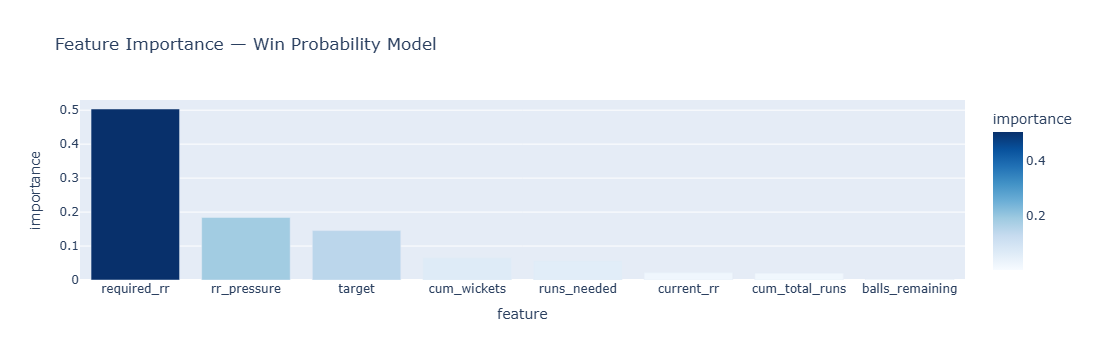

In [10]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(f"                 Predicted Loss  Predicted Win")
print(f"Actual Loss      {cm[0][0]:>14}  {cm[0][1]:>13}")
print(f"Actual Win       {cm[1][0]:>14}  {cm[1][1]:>13}")

# Feature importance — what does the model rely on most?
importance_df = pd.DataFrame({
    "feature":   features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nFeature Importances:")
print(importance_df)

fig = px.bar(importance_df, x="feature", y="importance",
             title="Feature Importance — Win Probability Model",
             color="importance",
             color_continuous_scale="Blues")
fig.show()

Match: Adelaide Strikers vs Brisbane Heat
Target: 207
Actual Winner: Brisbane Heat


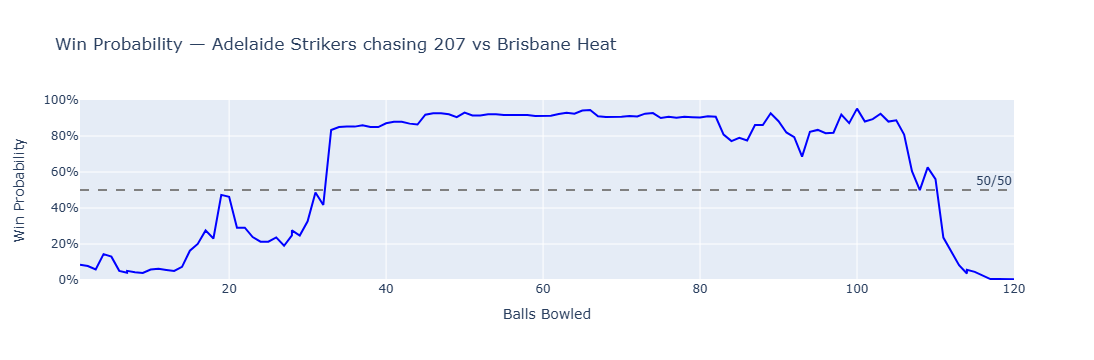

In [11]:
# Pick a match to visualise
sample_match_id = test_df["match_id"].iloc[0]
sample_match    = model_df[model_df["match_id"] == sample_match_id].copy()

# Get match details
batting_team  = sample_match["batting_team"].iloc[0]
bowling_team  = sample_match["bowling_team"].iloc[0]
target        = sample_match["target"].iloc[0]
actual_winner = sample_match["winner"].iloc[0]

# Predict win probability for every ball
sample_match["win_prob"] = model.predict_proba(sample_match[features])[:, 1]

print(f"Match: {batting_team} vs {bowling_team}")
print(f"Target: {target}")
print(f"Actual Winner: {actual_winner}")

# Plot win probability ball by ball
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=sample_match["balls_bowled"],
    y=sample_match["win_prob"],
    mode="lines",
    name=f"{batting_team} Win Probability",
    line=dict(color="blue", width=2)
))

fig.add_hline(y=0.5, line_dash="dash", line_color="gray",
              annotation_text="50/50")

fig.update_layout(
    title=f"Win Probability — {batting_team} chasing {target} vs {bowling_team}",
    xaxis_title="Balls Bowled",
    yaxis_title="Win Probability",
    yaxis=dict(tickformat=".0%", range=[0, 1])
)

fig.show()

In [12]:
# Save model to app folder
model_path = r"C:\Users\HP\OneDrive\Desktop\bbl-cricket-dashboard\app\model.pkl"

with open(model_path, "wb") as f:
    pickle.dump(model, f)

# Save the test match data for dashboard demo
sample_match.to_parquet(
    r"C:\Users\HP\OneDrive\Desktop\bbl-cricket-dashboard\data\processed\sample_match.parquet",
    index=False
)

# Save model_df for dashboard use
model_df.to_parquet(
    r"C:\Users\HP\OneDrive\Desktop\bbl-cricket-dashboard\data\processed\model_df.parquet",
    index=False
)

print("✅ Model saved to app/model.pkl")
print("✅ Sample match saved")
print("✅ Model dataframe saved")

✅ Model saved to app/model.pkl
✅ Sample match saved
✅ Model dataframe saved
